# PyMultiNest con datos de Pantheon+ para estimar $\Omega_\Lambda$

#### Cargamos paquetes necesarios

In [2]:
import json
import numpy as np
import pymultinest
import matplotlib.pyplot as plt
import os
import emcee
import corner
import time
os.makedirs("Omega_L", exist_ok=True)

In [3]:
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import WMAP9
from astropy.cosmology import LambdaCDM
from astropy.cosmology import wCDM
from astropy.cosmology import w0waCDM

Definimos H0 y temperatura del CMB con valores de WMAP9

In [4]:
H0_units = WMAP9.H(0)
H_0 = H0_units.value
Tcmb0_units = WMAP9.Tcmb(0)
Tcmb_0 = Tcmb0_units.value

Cargamos los datos (reducidos) de Pantheon+

In [5]:
data = np.loadtxt('data.dat')
z = data[:,0]
color = data[:,2]
x1 = data[:,3]
mb = data[:,5]

In [6]:
cov_data = np.loadtxt('Pantheon+SH0ES_STATONLY.cov', skiprows = 1)
cov_matrix = cov_data.reshape((1701,1701))
cov_matrix_inv = np.linalg.inv(cov_matrix)

Hasta aquí todo igual al ejercicio original de SN



#### **Modelo $\Omega_\Lambda$**

A continuación, definimos la función de la distancia modulo para los datos tal que el parámetro de densidad de Energía Oscura (o Materia Oscura) sea libre:

In [40]:
def mu_datos(z, H, Tcmb, OL_0):
    cosmo = FlatLambdaCDM(H0 = H_0, Tcmb0 = Tcmb_0, Om0 = 1-OL_0)
    dl = cosmo.luminosity_distance(z).value
    return 5*np.log10(dl*100000) 

In [39]:
## Copiamos el likelihood de ejercicios anteriores (ahora el vector de parámetros se llama cube para
# que no haya confusión con el ejemplo del tutorial

def loglike_L(cube, ndim, nparams):
    
    #alpha, beta, M = cube
    alpha = cube[0]
    beta = cube[1]
    M = cube[2]
    OL_0 = cube[3]
    #beta = 3.0
    #alpha = 0.14
    
    """t0 = time.time()"""
    
    mu_i = mu_datos(z, H_0, Tcmb_0, OL_0)
    
    """t1 = time.time()"""
    
    delta = mu_i - (mb+ alpha*x1- beta*color- M)
    chi2 = delta @ cov_matrix_inv @ delta
    
    """t2 = time.time()
    print("Tiempo cosmología:", t1-t0)
    print("Tiempo chi2:", t2-t1)"""
    
    return -chi2

In [38]:
## Generamos un prior similar al del tutorial
bounds = np.array([[-2., 2.],[-5., 5.],[-21., -15.], [0.0, 1.0]])  ### Como vamos a estimar Om actual, no hay problema con el límite inferior.
#bounds = np.array([[-21., -15.]])                                  ## si fueramos a estimar Om para tiempos muy tempranos sí habría problema

def prior(cube, ndim, nparams):
    for i in range(ndim):
        low  = bounds[i,0]
        high = bounds[i,1]
        cube[i] = low + (high-low)*cube[i]    ## el parámetro está entre el valor minimo y maximo de 'bounds'

Corremos PyMultiNest, solo necesitamos las funciones de likelihood y prior con las mismas dependencias de parámetros _(cube, ndim, nparams)_. 

In [41]:
## Para medir tiempos de calculos de astropy y chi2 usar función loglike comentada
test = loglike_L([0.14, 3.0, -19.3, 0.7], 4, 4)
print(test)

-2261.0167280069622


**Lo pesado son los calculos de astropy, no el ajuste**

In [10]:
parameters = ["a", "b", "M", "OL0"]
ndim = len(parameters)


inicio = time.time()

pymultinest.run(
    loglike_L,
    prior,
    ndim,
    outputfiles_basename='Omega_L/',
    resume=False,
    verbose=False
)


fin = time.time()

json.dump(parameters, open('Omega_L/params.json', 'w'))
print(f"Tiempo total: {(fin - inicio)/60:.2f} minutos")

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    4
 *****************************************************
 ln(ev)=  -2023.6801537867802      +/-  0.22362372241864900     
 Total Likelihood Evaluations:        12946
 Sampling finished. Exiting MultiNest
Tiempo total: 4.71 minutos


  analysing data from Omega_L/.txt


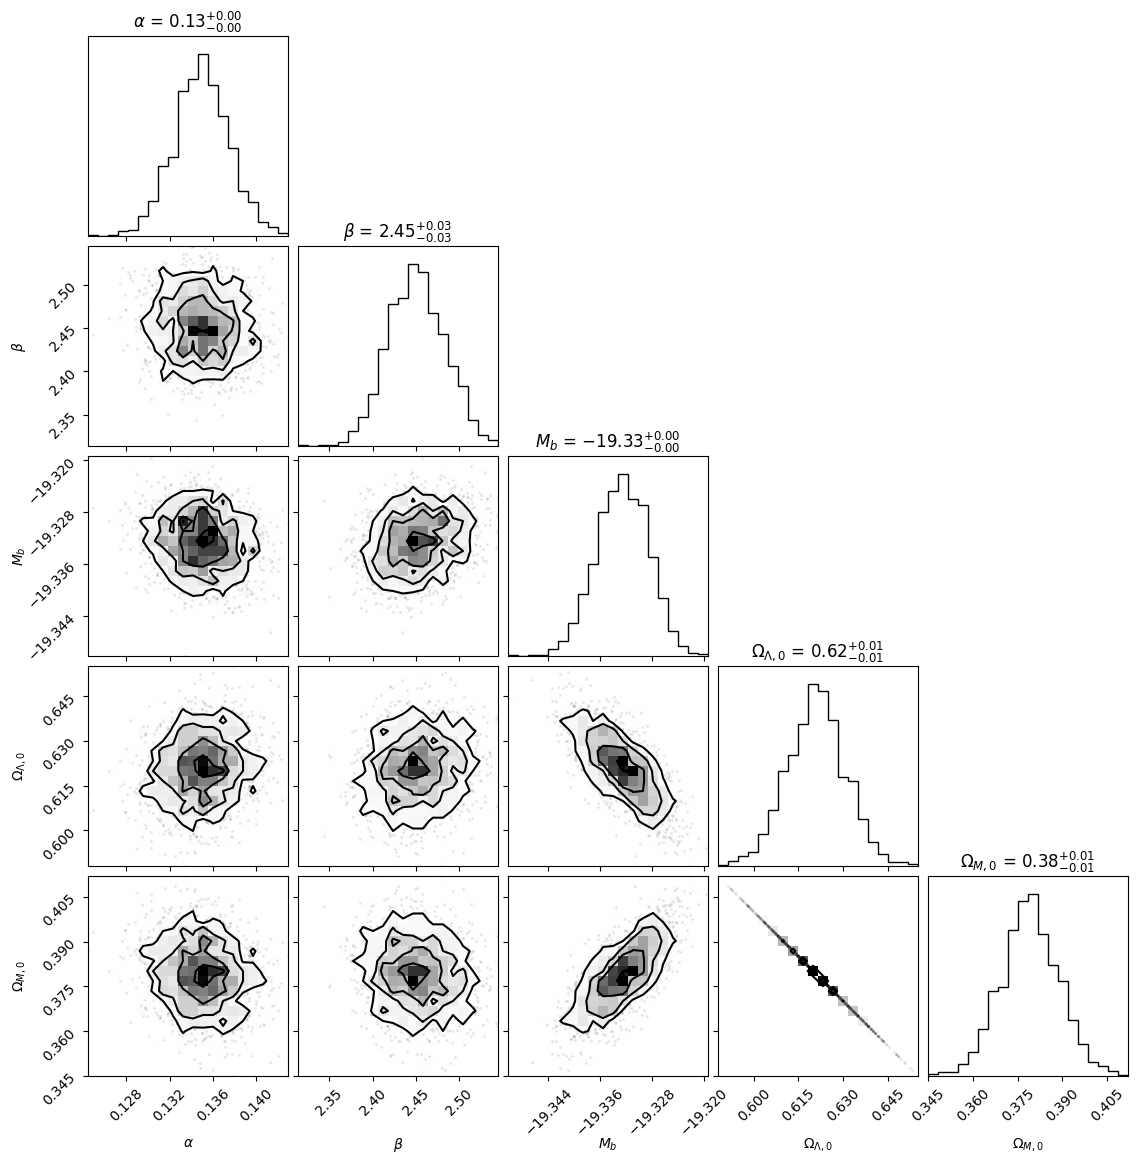

In [21]:
a = pymultinest.Analyzer(
    n_params=ndim,
    outputfiles_basename='Omega_L/'
)

samples = a.get_equal_weighted_posterior()

############################################
##### INCLUIR O_M EN LOS CORNER PLOTS  #####

# Se paramos la cadena de O_L
chains = samples[:, :-1]            ## samples[filas, columnas] -> samples[:,:-1] = toma 
                                     # todas las filas, todas las columnas, excepto la útlima
Omega_L = chains[:, -1]             ## toma la útlma cadena porque chains = ["a","b","M",OL"]
Omega_M = 1.0 - Omega_L

# agregarmos O_M
new_chains = np.column_stack((chains, Omega_M))

corner.corner(
    new_chains,
    labels=[r"$\alpha$", r"$\beta$", "$M_b$", r"$\Omega_{\Lambda,0}$", r"$\Omega_{M,0}$"],
    show_titles=True
)

plt.show()

## Para un universo con curvatura:

In [16]:
def mu_datos(z, H_0, Tcmb_0, OL_0, Om_0):
    cosmo = LambdaCDM(H0 = H_0, Tcmb0 = Tcmb_0, Ode0 = OL_0, Om0 = Om_0)
    #Ok0 = cosmo.Ok0
    dl = cosmo.luminosity_distance(z).value
    return 5*np.log10(dl*100000)

In [18]:
mu_i = mu_datos(0.1, 0.7, 2.3, 0.5, 0.01)

In [19]:
bounds = np.array([[-2., 2.],[-5., 5.],[-21., -15.], [0., 1.], [0., 1.]])

def prior(cube, ndim, nparams):
    for i in range(ndim):
        low  = bounds[i,0]
        high = bounds[i,1]
        cube[i] = low + (high-low)*cube[i]

In [20]:
def loglike_k(cube, ndim, nparams):
    
    #alpha, beta, M = cube
    alpha = cube[0]
    beta = cube[1]
    M = cube[2]
    OL_0 = cube[3]
    Om_0 = cube[4]
    #beta = 3.0
    #alpha = 0.14
    
    """t0 = time.time()"""
    
    mu_i = mu_datos(z, H_0, Tcmb_0, OL_0, Om_0)
    
    """t1 = time.time()"""
    
    delta = mu_i - (mb+ alpha*x1- beta*color- M)
    chi2 = delta @ cov_matrix_inv @ delta
    
    """t2 = time.time()
    print("Tiempo cosmología:", t1-t0)
    print("Tiempo chi2:", t2-t1)"""
    
    return -chi2

In [21]:
os.makedirs("Omega_k", exist_ok=True)     ## Creamos una nueva carpeta para guardar los datos

parameters = ["a", "b", "M", "OL0", "Om0"]
ndim = len(parameters)


inicio = time.time()

pymultinest.run(
    loglike_k,
    prior,
    ndim,
    outputfiles_basename='Omega_k/',
    resume=False,
    verbose=False
)


fin = time.time()

json.dump(parameters, open('Omega_k/params.json', 'w'))
print(f"Tiempo total: {(fin - inicio)/60:.2f} minutos")

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    5
 *****************************************************
 ln(ev)=  -2012.7864379757830      +/-  0.22637530433620412     
 Total Likelihood Evaluations:        18091
 Sampling finished. Exiting MultiNest
Tiempo total: 6.48 minutos


In [18]:
a = pymultinest.Analyzer(
    n_params=ndim,
    outputfiles_basename='Omega_k/'
)

samples = a.get_equal_weighted_posterior()

  analysing data from Omega_k/.txt


Obtenemos $\Omega_k$ de la restricción de Friedmann:
\begin{equation}
\Omega_k = 1 - \Omega_M - \Omega_\Lambda
\end{equation}
asumiendo $\Omega_r \approx 0$

IndexError: list index out of range

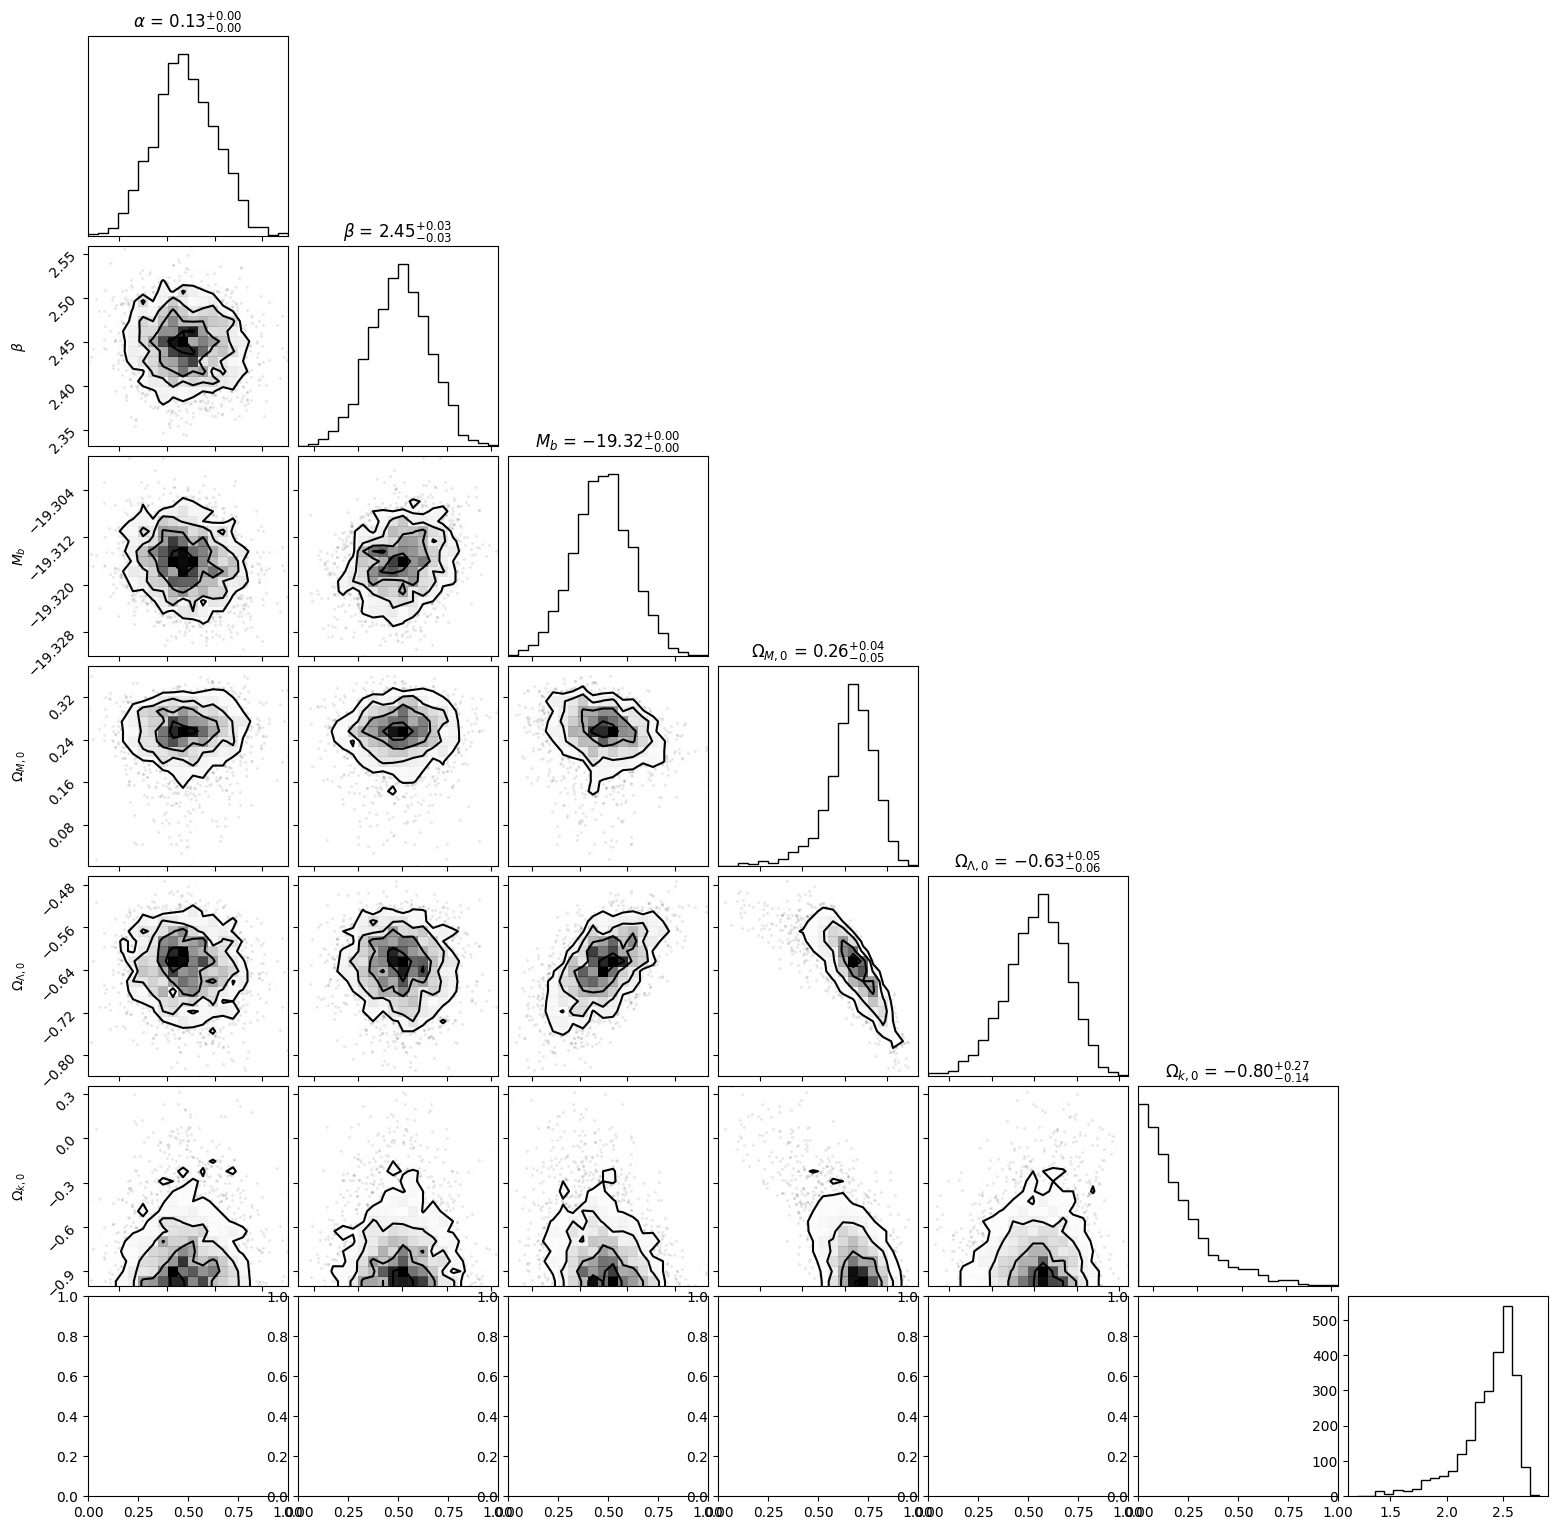

In [42]:
# Se paramos la cadena de O_L
chains = samples[:, :-1]            ## samples[filas, columnas] -> samples[:,:-1] = toma 
                                     # todas las filas, todas las columnas, excepto la útlima
Omega_L = chains[:, -2]             ## toma la útlma cadena porque chains = ["a","b","M","OL","OM"]
Omega_M = chains[:, -1]
Omega_k = 1- Omega_M - Omega_L

# agregarmos O_M
new_chains = np.column_stack((chains, Omega_k))

corner.corner(
    new_chains,
    labels=[r"$\alpha$", r"$\beta$", "$M_b$", r"$\Omega_{M,0}$", r"$\Omega_{\Lambda,0}$", r"$\Omega_{k,0}$"],
    show_titles=True
)

plt.show()

In [ ]:
raise Exception("stop")

## Universo $w$CDM

In [7]:
def loglike_w(cube, ndim, nparams):     
    
    #alpha, beta, M = cube
    alpha = cube[0]
    beta = cube[1]
    M = cube[2]
    Om_0 = cube[3]
    w_0 = cube[4]                        
    #beta = 3.0
    #alpha = 0.14
    
    """t0 = time.time()"""
    
    mu_i = mu_datos(z, H_0, Om_0, w_0)   
    
    """t1 = time.time()"""
    
    delta = mu_i - (mb+ alpha*x1- beta*color- M)
    chi2 = delta @ cov_matrix_inv @ delta
    
    """t2 = time.time()
    print("Tiempo cosmología:", t1-t0)
    print("Tiempo chi2:", t2-t1)"""
    
    return -chi2

In [8]:
def mu_datos(z, H_0, Om_0, w_0):                   
    cosmo = wCDM(H0 = H_0, Om0=Om_0, Ode0=1 - Om_0, w0=w_0)  
    dl = cosmo.luminosity_distance(z).value
    return 5*np.log10(dl*100000)

def prior(cube, ndim, nparams):
    for i in range(ndim):
        low  = bounds[i,0]
        high = bounds[i,1]
        cube[i] = low + (high-low)*cube[i]

bounds = np.array([[-2., 2.],[-5., 5.],[-21., -15.], [0., 1.], [-1., 1.]]) 
mu_test = mu_datos(0.1, 0.7, 0.3, -0.9)              

In [9]:
mu_test

48.304880151000525

In [10]:
os.makedirs("Omega_w", exist_ok=True)     ## Creamos una nueva carpeta para guardar los datos

parameters = ["a", "b", "M", "Om0", "w"]  
ndim = len(parameters)


inicio = time.time()

pymultinest.run(
    loglike_w,                                 
    prior,
    ndim,
    outputfiles_basename='Omega_w/',            
    resume=False,
    verbose=False
)


fin = time.time()

json.dump(parameters, open('Omega_w/params.json', 'w'))  
print(f"Tiempo total: {(fin - inicio)/60:.2f} minutos")

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    5
 *****************************************************
Tiempo total: 9.75 minutos ln(ev)=  -2011.7911477473599      +/-  0.22898054056769826     
 Total Likelihood Evaluations:        23021
 Sampling finished. Exiting MultiNest



  analysing data from Omega_w/.txt


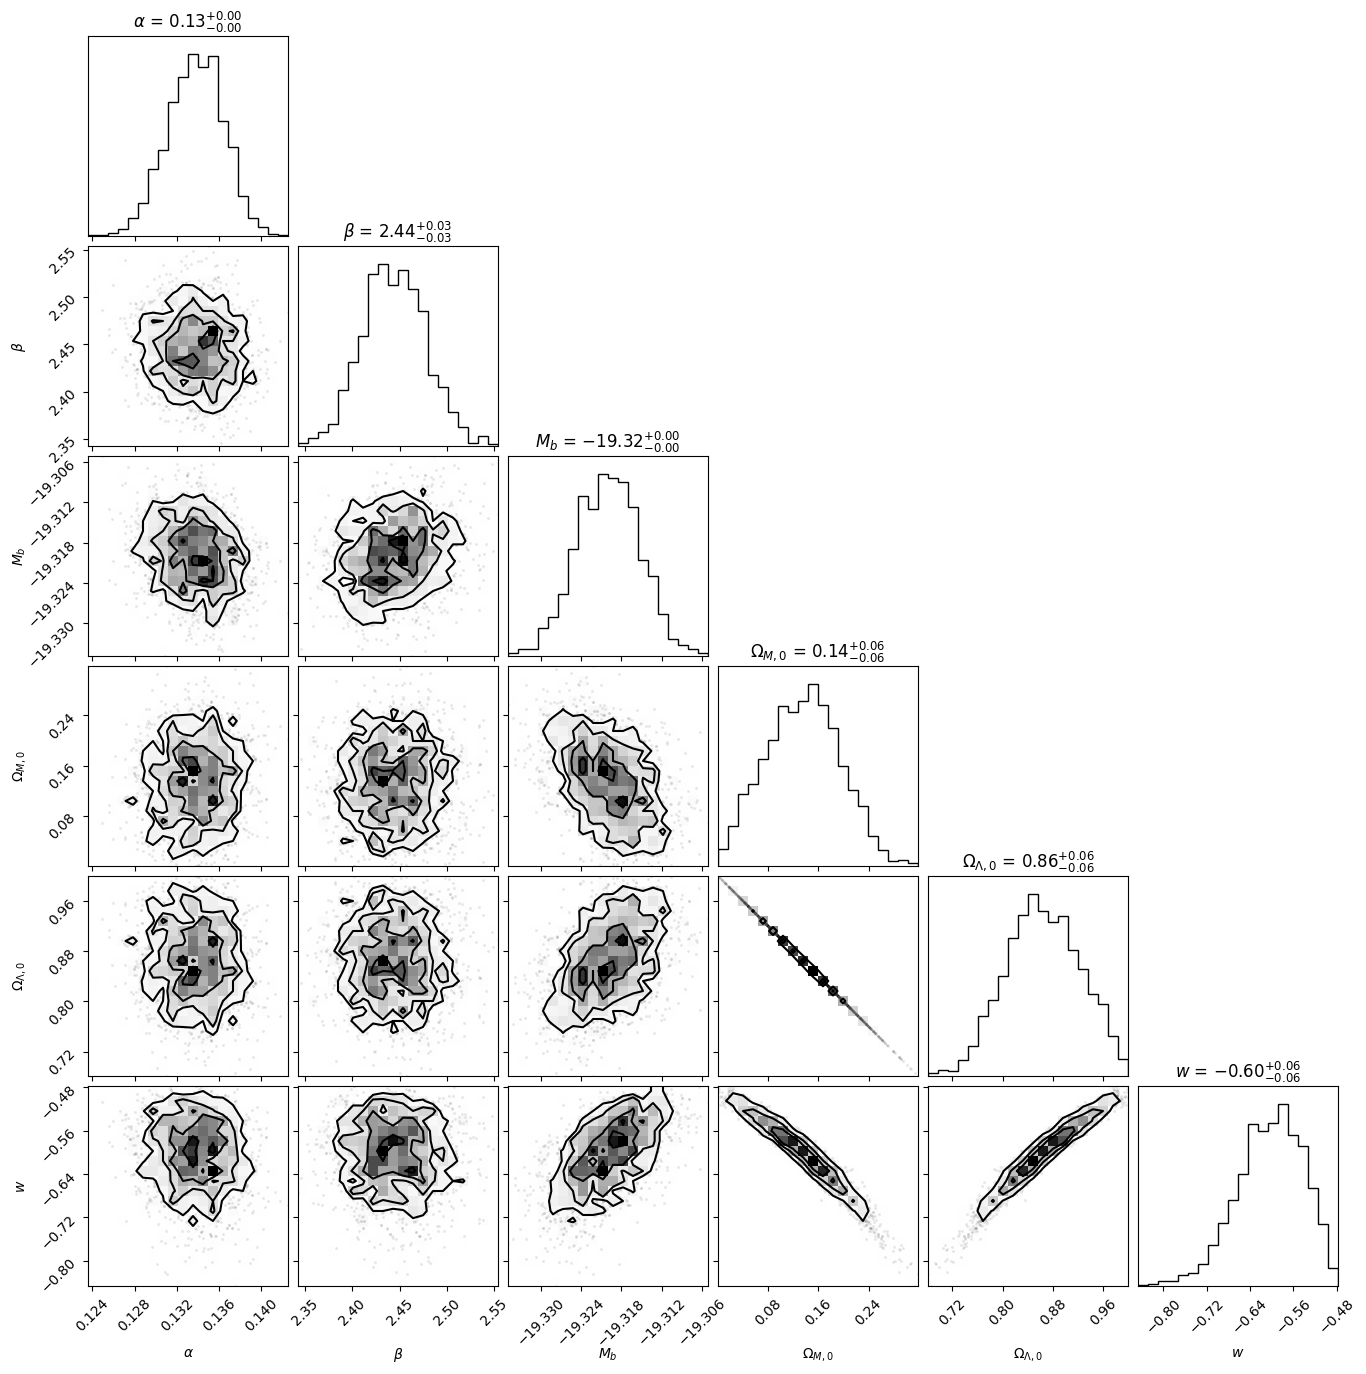

In [17]:
a = pymultinest.Analyzer(
    n_params=ndim,
    outputfiles_basename='Omega_w/'  
)

samples = a.get_equal_weighted_posterior()

# Se paramos la cadena la última columna que es el ajuste chi2

chains = samples[:, :-1]            ## samples[filas, columnas] -> samples[:,:-1] = toma 
                                     # todas las filas, todas las columnas, excepto la útlima
Omega_M = chains[:, -2]             ## toma la útlma cadena porque chains = ["a","b","M",Om","w"]
Omega_L = 1- Omega_M

# agregarmos O_L
new_chains = np.insert(chains, 4, Omega_L, axis=1)

corner.corner(
    new_chains,
    labels= [r"$\alpha$", r"$\beta$", "$M_b$", r"$\Omega_{M,0}$", r"$\Omega_{\Lambda,0}$", r"$w$"],
    show_titles=True
)

plt.show()

## Universo $w_0 w_a$CDM

In [22]:
def mu_datos(z, H_0, Om_0, w_0, w_a):
    cosmo = w0waCDM(H0=H_0, Om0=Om_0, Ode0=1 - Om_0, w0=w_0, wa=w_a)
    dl = cosmo.luminosity_distance(z).value
    return 5*np.log10(dl*100000)

def prior(cube, ndim, nparams):
    for i in range(ndim):
        low  = bounds[i,0]
        high = bounds[i,1]
        cube[i] = low + (high-low)*cube[i]

def loglike_wa(cube, ndim, nparams): 
    
    #alpha, beta, M = cube
    alpha = cube[0]
    beta = cube[1]
    M = cube[2]
    Om_0 = cube[3]
    w_0 = cube[4]                  
    w_a = cube[5]
    #beta = 3.0
    #alpha = 0.14
    
    """t0 = time.time()"""
    
    mu_i = mu_datos(z, H_0, Om_0, w_0, w_a)  
    
    """t1 = time.time()"""
    
    delta = mu_i - (mb+ alpha*x1- beta*color- M)
    chi2 = delta @ cov_matrix_inv @ delta
    
    """t2 = time.time()
    print("Tiempo cosmología:", t1-t0)
    print("Tiempo chi2:", t2-t1)"""
    
    return -chi2


bounds = np.array([[-2., 2.],[-5., 5.],[-21., -15.], [0., 1.], [-1., 1.], [-1., 1.]])
mu_test = mu_datos(0.1, 0.7, 0.3, -0.9, 0.2) 

In [23]:
mu_test

48.30424027296499

In [24]:
os.makedirs("Omega_wa", exist_ok=True) 

parameters = ["a", "b", "M", "Om0", "w", "wa"]  
ndim = len(parameters)


inicio = time.time()

pymultinest.run(
    loglike_wa,                                
    prior,
    ndim,
    outputfiles_basename='Omega_wa/',            
    resume=False,
    verbose=False
)


fin = time.time()

json.dump(parameters, open('Omega_wa/params.json', 'w')) 
print(f"Tiempo total: {(fin - inicio)/60:.2f} minutos")

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    6
 *****************************************************
Tiempo total: 11.93 minutos ln(ev)=  -2009.7254666859990      +/-  0.23417272151686594     
 Total Likelihood Evaluations:        30175
 Sampling finished. Exiting MultiNest



  analysing data from Omega_wa/.txt


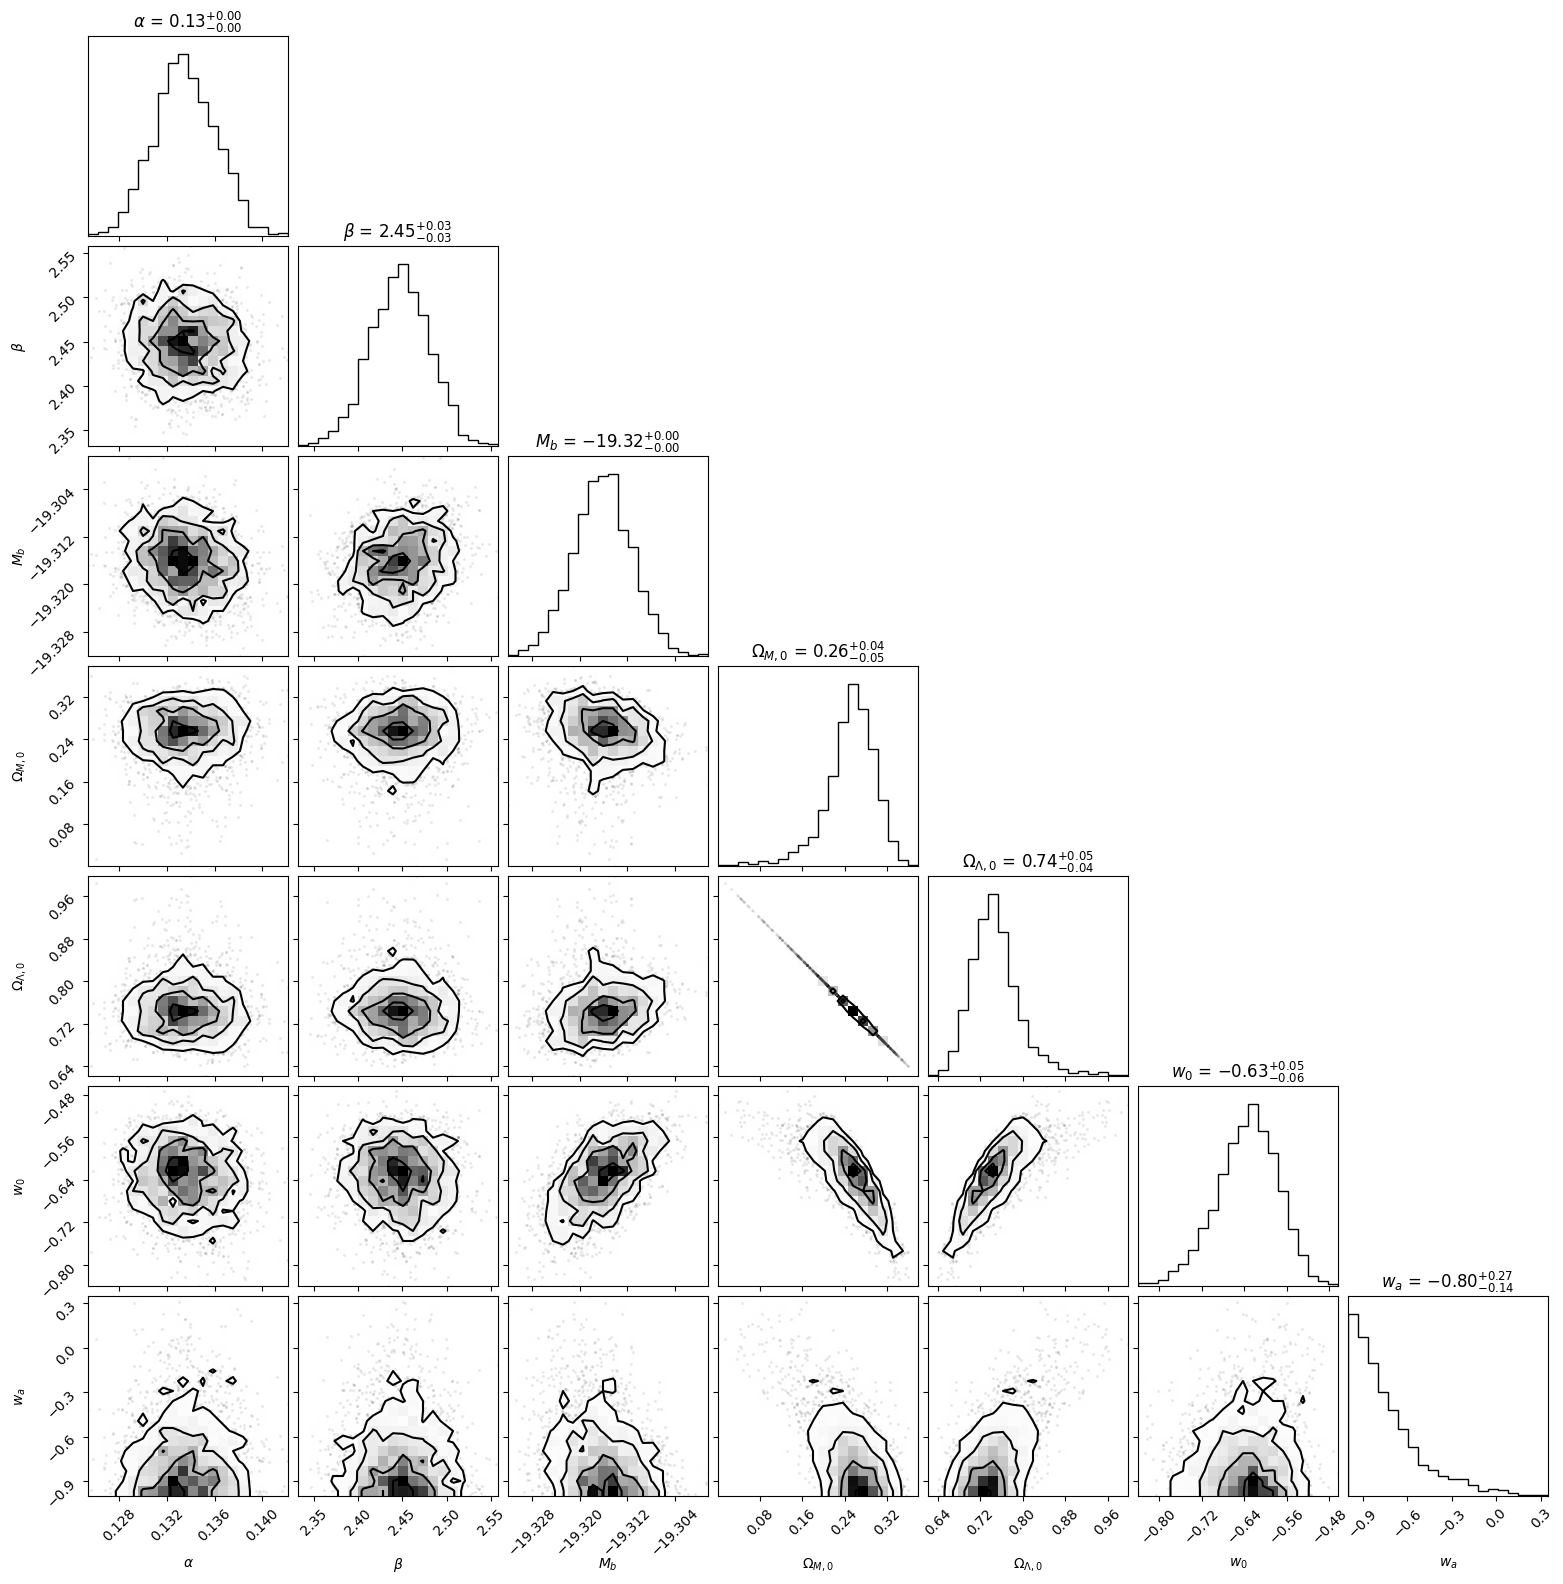

In [25]:
a = pymultinest.Analyzer(
    n_params=ndim,
    outputfiles_basename='Omega_wa/'  
)

samples = a.get_equal_weighted_posterior()

# Se paramos la cadena la última columna que es el ajuste chi2

chains = samples[:, :-1]            ## samples[filas, columnas] -> samples[:,:-1] = toma 
                                     # todas las filas, todas las columnas, excepto la útlima
Omega_M = chains[:, -3]             ## toma la útlma cadena porque chains = ["a","b","M",Om","w0","wa"]
Omega_L = 1- Omega_M

# agregarmos O_L
new_chains = np.insert(chains, 4, Omega_L, axis=1)

corner.corner(
    new_chains,
    labels=[r"$\alpha$", r"$\beta$", "$M_b$", r"$\Omega_{M,0}$", r"$\Omega_{\Lambda,0}$", r"$w_0$", r"$w_a$"],
    show_titles=True
)

plt.show()

Notas:
- Los modelo $wCDM$ y $w_0w_aCDM$ están muy degenerados, repetir para k=0 y ver si salen valores más cercanos a los estándar?